In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [16]:
df.shape

(1000, 15)

In [4]:
df = df.drop('student_id', axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [7]:
100*df.isnull().sum()/df.shape[0]

,0
age,0.0
gender,0.0
study_hours_per_day,0.0
social_media_hours,0.0
netflix_hours,0.0
part_time_job,0.0
attendance_percentage,0.0
sleep_hours,0.0
diet_quality,0.0
exercise_frequency,0.0


In [8]:
df['parental_education_level'].value_counts()

,count
parental_education_level,
High School,392
Bachelor,350
Master,167


In [9]:
df['parental_education_level'].mode()[0]

'High School'

In [10]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [11]:
df.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


In [12]:
df.corr(numeric_only=True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.003971,-0.009151,-0.001174,-0.026055,0.037482,-0.003836,-0.045101,-0.008907
study_hours_per_day,0.003971,1.000000,0.020282,-0.031158,0.026264,-0.027757,-0.028701,-0.003768,0.825419
social_media_hours,-0.009151,0.020282,1.000000,0.011477,0.040479,0.018236,-0.037319,0.001496,-0.166733
netflix_hours,-0.001174,-0.031158,0.011477,1.000000,-0.002092,-0.000935,-0.006448,0.008034,-0.171779
attendance_percentage,-0.026055,0.026264,0.040479,-0.002092,1.000000,0.013756,-0.007857,-0.018745,0.089836
sleep_hours,0.037482,-0.027757,0.018236,-0.000935,0.013756,1.000000,0.019769,-0.006508,0.121683
exercise_frequency,-0.003836,-0.028701,-0.037319,-0.006448,-0.007857,0.019769,1.000000,-0.000242,0.160107
mental_health_rating,-0.045101,-0.003768,0.001496,0.008034,-0.018745,-0.006508,-0.000242,1.000000,0.321523
exam_score,-0.008907,0.825419,-0.166733,-0.171779,0.089836,0.121683,0.160107,0.321523,1.000000


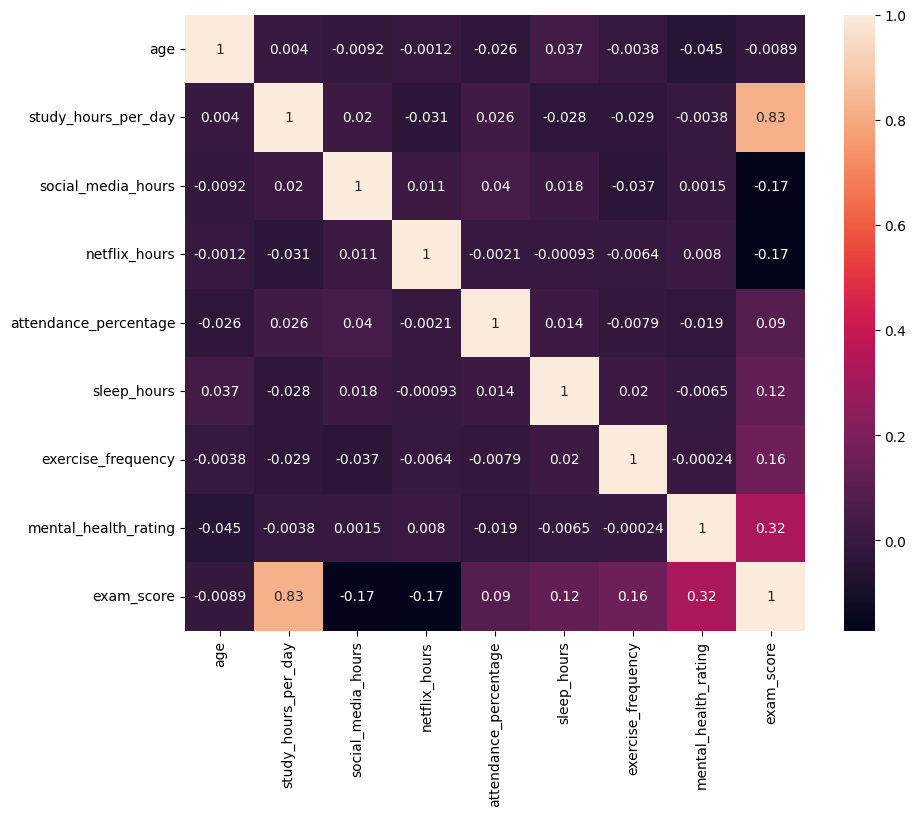

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [14]:
df.corr(numeric_only=True)['exam_score'].sort_values()

,exam_score
netflix_hours,-0.171779
social_media_hours,-0.166733
age,-0.008907
attendance_percentage,0.089836
sleep_hours,0.121683
exercise_frequency,0.160107
mental_health_rating,0.321523
study_hours_per_day,0.825419
exam_score,1.000000


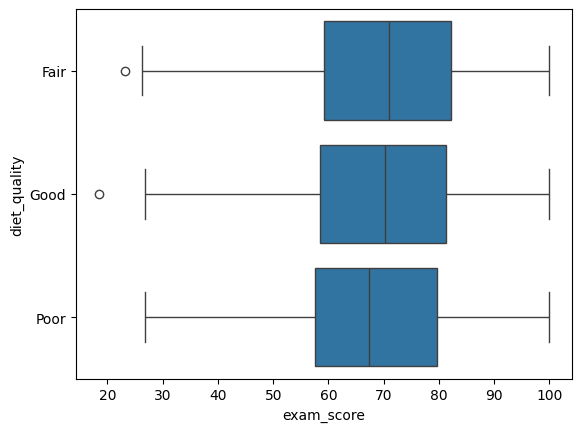

In [15]:
sns.boxplot(x='exam_score', y='diet_quality', data=df);

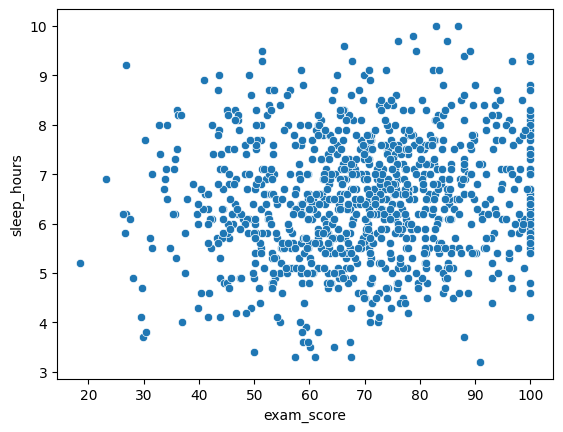

In [18]:
sns.scatterplot(x='exam_score', y='sleep_hours', data=df);

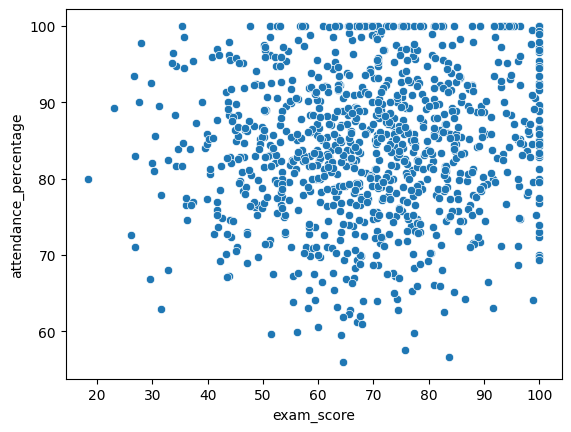

In [19]:
sns.scatterplot(x='exam_score', y='attendance_percentage', data=df);

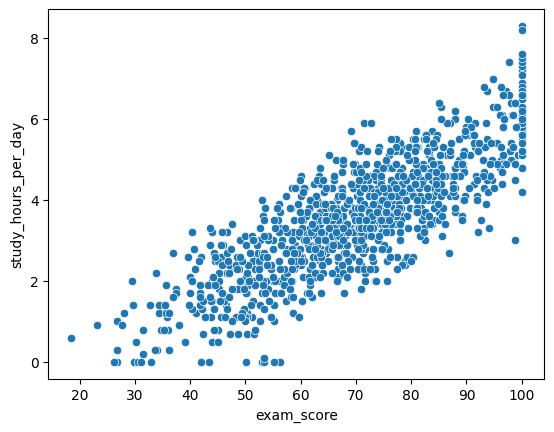

In [20]:
sns.scatterplot(x='exam_score', y='study_hours_per_day', data=df);

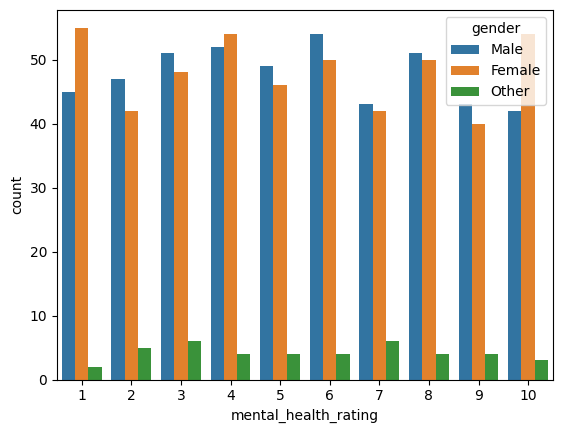

In [21]:
sns.countplot(x='mental_health_rating', hue='gender', data=df);

In [22]:
df.groupby('gender')['mental_health_rating'].sum()

,mental_health_rating
gender,
Female,2623
Male,2585
Other,230


In [23]:
#Méthode IQR pour les colonnes exam_score et study_hours_per_day
colonne = ['exam_score', 'study_hours_per_day']

In [24]:
for colonne in colonne:
  Q3 = df[colonne].quantile(0.75)
  Q1 = df[colonne].quantile(0.25)
  IQR = Q3 - Q1
  outliers = df[(df[colonne] < (Q1 - 1.5*IQR))|(df[colonne] > (Q3 + 1.5*IQR))]
  print(outliers)
  print()
  print(f'Pour la colonne {colonne}, il y a {outliers.shape[0]} outliers')

     age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
265   18  Female                  0.6                 3.1            3.0   
327   23    Male                  0.9                 2.4            2.5   

    part_time_job  attendance_percentage  sleep_hours diet_quality  \
265            No                   79.9          5.2         Good   
327            No                   89.2          6.9         Fair   

     exercise_frequency parental_education_level internet_quality  \
265                   1                 Bachelor             Good   
327                   0              High School             Poor   

     mental_health_rating extracurricular_participation  exam_score  
265                     4                            No        18.4  
327                     1                            No        23.1  

Pour la colonne exam_score, il y a 2 outliers
     age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
73    18  Female   

In [25]:
num = df.select_dtypes(exclude='object')
obj = df.select_dtypes(include='object')

In [26]:
dumies = pd.get_dummies(obj, drop_first=True)

In [27]:
df_final = pd.concat([num, dumies], axis=1)

In [28]:
df_final.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,False,False,False,False,False,False,True,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,False,False,False,True,False,True,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,True,False,False,False,True,True,False,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,False,False,False,False,True,False,True,True,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,False,False,False,False,False,False,True,True,False,False


In [29]:
X = df_final.drop('exam_score',axis=1)
y = df_final['exam_score']

In [30]:
X.shape, y.shape

((1000, 18), (1000,))

In [31]:
y = df_final['exam_score'].values.reshape(-1,1)

In [32]:
y.shape

(1000, 1)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [38]:
scaler = StandardScaler()

#Regression Linéaire

In [39]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [40]:
X_train_lin=np.hstack((X_train_scale,np.ones((X_train_scale.shape[0],1))))
X_test_lin= np.hstack((X_test_scale, np.ones((X_test_scale.shape[0], 1))))

In [41]:
X_test_lin

array([[ 1.07626887, -0.02829565, -0.34149655, ..., -0.42478047,
        -0.6882472 ,  1.        ],
       [ 0.2083101 ,  1.61090038,  1.78601846, ..., -0.42478047,
         1.45296631,  1.        ],
       [ 1.07626887,  0.6547027 , -0.08619475, ..., -0.42478047,
         1.45296631,  1.        ],
       ...,
       [-1.52760743, -0.84789366, -0.85210015, ..., -0.42478047,
        -0.6882472 ,  1.        ],
       [ 0.2083101 ,  0.51810303, -1.27760316, ..., -0.42478047,
        -0.6882472 ,  1.        ],
       [-1.09362804, -1.39429233,  0.42440885, ..., -0.42478047,
        -0.6882472 ,  1.        ]])

In [43]:
X_train_lin.shape

(700, 19)

In [42]:
X_test_lin.shape

(300, 19)

In [46]:
theta = np.random.rand(X_train_lin.shape[1],1)

In [47]:
theta

array([[0.30471573],
       [0.00197977],
       [0.89381165],
       [0.70178788],
       [0.92433061],
       [0.00352885],
       [0.50585056],
       [0.25141369],
       [0.14857416],
       [0.15413265],
       [0.77938822],
       [0.89734348],
       [0.28992531],
       [0.18803557],
       [0.84936632],
       [0.63839341],
       [0.49820709],
       [0.87720194],
       [0.36211368]])

In [48]:
theta.shape

(19, 1)

In [49]:
#Implémentation de la fonction du modèle
def model(X,theta):
    return X.dot(theta)

In [50]:
# Implémentation de la fonction de cout
def cost_function(X,y,theta):
    m=len(y)
    return 1/(2*m) * np.sum((model(X,theta)-y)**2)

In [51]:
cost_function(X_train_lin,y_train,theta)

np.float64(2565.0818692452594)

In [52]:
# Implémentation du gradient

def gradient(X,y,theta):
    m=len(y)
    return 1/m * X.T.dot(model(X,theta)-y)

In [53]:
#Implémentation du gradient descent
def gradient_descent(X,y,theta,learning_rate,n_iterations):
    cost_history=np.zeros(n_iterations)
    for i in range (0,n_iterations):
        theta=theta-learning_rate*gradient(X,y,theta)
        cost_history[i]=cost_function(X,y,theta)
    return theta,cost_history

In [54]:
theta_final,cost_history=gradient_descent(X_train_lin,y_train,theta,learning_rate=0.01,n_iterations=1000)

In [55]:
theta_final

array([[ 1.46396700e-01],
       [ 1.40326305e+01],
       [-3.20264533e+00],
       [-2.61059059e+00],
       [ 1.36535577e+00],
       [ 2.47135036e+00],
       [ 2.58515886e+00],
       [ 5.53352130e+00],
       [ 1.50907201e-01],
       [ 1.53765804e-01],
       [ 7.91248464e-03],
       [-4.78347333e-01],
       [-2.29272400e-01],
       [-2.40806484e-01],
       [-4.19972621e-02],
       [-7.81981957e-02],
       [-3.63858562e-02],
       [-3.43529457e-02],
       [ 6.98765703e+01]])

In [56]:
predictions_train=model(X_train_lin,theta_final)

In [57]:
predictions_test=model(X_test_lin,theta_final)

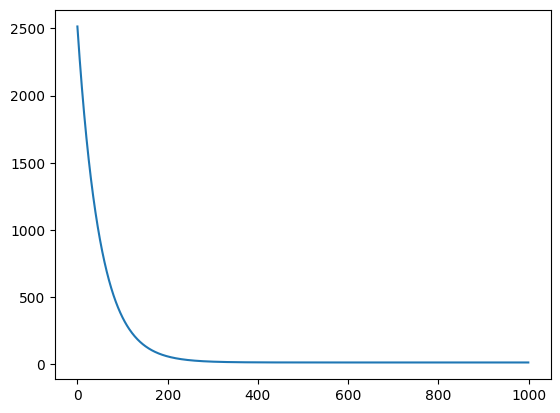

In [58]:
plt.plot(range(1000),cost_history);

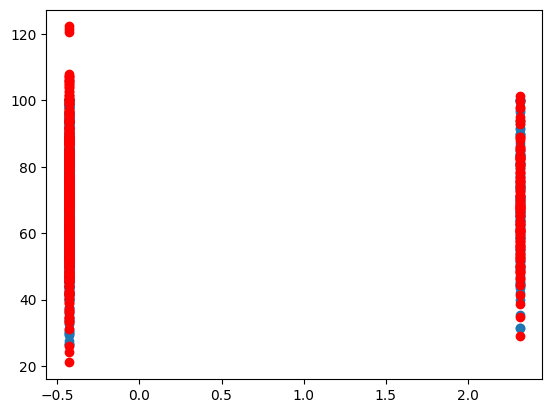

In [59]:
#visualisation par rapport à la 2eme variable
plt.scatter(X_train_lin[:,14],y_train)
plt.scatter(X_train_lin[:,14],predictions_train,c="r");

In [60]:
def coefficient_determination(y,pred):
    u=((y-pred)**2).sum()
    v=((y-y.mean())**2).sum()
    return 1- u/v

In [61]:
coefficient_determination(y_test,predictions_test)

np.float64(0.897127458224449)

In [62]:
def mean_square_error(y,pred):
    m=len(y)
    u=((y-pred)**2).sum()
    return 1/m * u

In [63]:
mean_square_error(y_test,predictions_test)

np.float64(28.574023922682198)

#Regression Polynômiale

In [65]:
x_poly=X**2

In [66]:
x_poly_train,x_poly_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)

In [68]:
x_poly_train_scaled=scaler.fit_transform(x_poly_train)
x_poly_test_scaled=scaler.transform(x_poly_test)

In [69]:
X_poly_train=np.hstack((x_poly_train_scaled,X_train_lin))
X_poly_test= np.hstack((x_poly_test_scaled, X_test_lin))

In [70]:
X_poly_train.shape

(700, 37)

In [71]:
X_poly_test.shape

(300, 37)

In [72]:
#Initialisation de theta
theta_poly=np.random.rand(X_poly_train.shape[1],1)

In [73]:
theta_final_poly,cost_history_poly=gradient_descent(X_poly_train,y_train,theta_poly,learning_rate=0.01,n_iterations=4000)

In [74]:
# Affichage des coefficients du modele
theta_final_poly

array([[ 7.33256092e-02],
       [-7.66374899e-01],
       [ 1.13671248e+00],
       [ 7.46799344e-02],
       [ 4.68863556e-01],
       [ 1.31383922e+00],
       [ 4.52683669e-01],
       [ 1.54487175e+00],
       [ 2.49494391e-01],
       [-7.59718034e-02],
       [-6.62804856e-03],
       [-3.56648893e-01],
       [ 7.20490815e-02],
       [ 7.67790526e-02],
       [ 2.02619955e-01],
       [-9.51689718e-02],
       [ 8.63753576e-02],
       [ 1.31895787e-01],
       [ 3.30960802e-02],
       [ 1.47113477e+01],
       [-4.26394011e+00],
       [-2.66739491e+00],
       [ 9.29625743e-01],
       [ 1.13892506e+00],
       [ 2.17382298e+00],
       [ 4.00711217e+00],
       [-8.81445593e-02],
       [ 2.34843895e-01],
       [-6.09736296e-03],
       [-1.39547572e-01],
       [-3.00254587e-01],
       [-3.09099009e-01],
       [-2.33724950e-01],
       [-2.02735357e-02],
       [-1.58042440e-01],
       [-1.45175462e-01],
       [ 6.98795714e+01]])

In [75]:
predictions_train_poly=model(X_poly_train,theta_final_poly)

In [76]:
predictions_test_poly=model(X_poly_test,theta_final_poly)

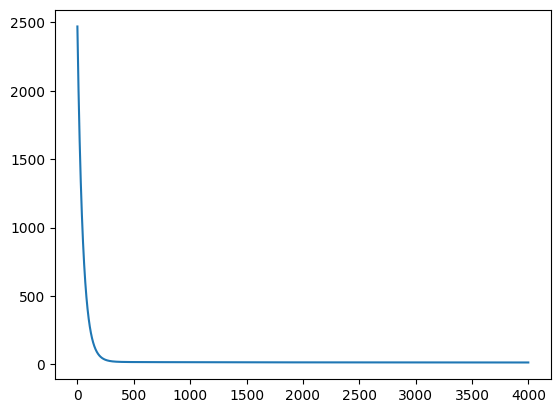

In [77]:
#Evolution de la fonction de coût
plt.plot(range(4000),cost_history_poly)
plt.show()

In [78]:
coefficient_determination(y_test,predictions_test_poly)

np.float64(0.8980584702299309)

In [79]:
mean_square_error(y_test,predictions_test_poly)

np.float64(28.315424700209523)

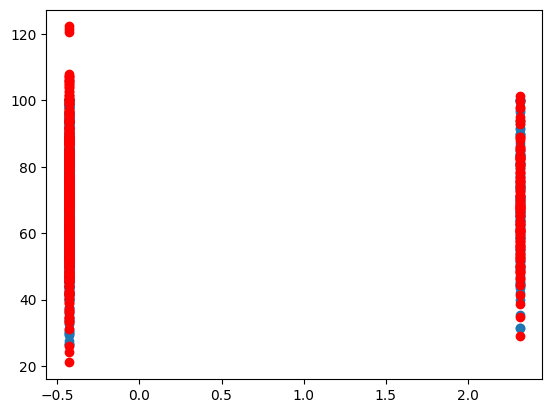

In [80]:
#visualisation par rapport à la 2eme variable
plt.scatter(X_poly_train[:,14],y_train)
plt.scatter(X_poly_train[:,14],predictions_train,c="r");

#Avec scikit-learn

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [82]:
model = LinearRegression()

In [83]:
model.fit(X_train_scale,y_train)

LinearRegression()

In [84]:
y_pred = model.predict(X_test_scale)

In [85]:
from sklearn.metrics import r2_score, mean_squared_error

In [86]:
r2_score(y_test,y_pred)

0.8971205742334323

In [88]:
poly = PolynomialFeatures(degree=2)

In [89]:
model.fit(poly.fit_transform(X_train_scale),y_train)

LinearRegression()

In [90]:
y_pred = model.predict(poly.fit_transform(X_test_scale))

In [91]:
r2_score(y_test,y_pred)

0.8835804118703267